# UMAP / t-SNE embedding visualisation

## 1 · Config

In [12]:
from pathlib import Path
from paths import load_paths

MODEL_NAME   = "satclip_open_clip_vit_h"  # keys: geoclip_geoyfcc, geoclip_geospatial_all, satclip_geospatial, satclip_geospatial_all, satclip_open_clip_vit_h_n500000
CONCEPT_DATASET = "git-10m"
CONCEPT_NAME = "geospatial_all"  # geospatial_all, geospatial
_paths = load_paths()
MODEL_PATH  = Path(_paths["models"][MODEL_NAME]["model_path"])
CONCEPT_SET = Path(_paths["concept_sets"][CONCEPT_DATASET][CONCEPT_NAME])
OUTPUT_DIR  = Path("figures/umap") / MODEL_NAME / CONCEPT_NAME

NUM_SAMPLES           = None  # None → use all
STRATIFY_BY_CONTINENT = True
LAT_COL, LON_COL = "lat", "lon"
LOCATIONS_PATH = Path("/home/libe2152/data/s2-100k/index.csv")

In [13]:
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

## 2 · Imports & model/data loading

In [14]:
import argparse, json, sys
import numpy as np, pandas as pd, torch
import matplotlib, matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from plot import (
    load_model, embed_locations, embed_concepts,
    center_renorm, get_continents, umap_reduce, _with_alpha,
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

device: cuda


In [15]:
if LOCATIONS_PATH is not None:
    loc_p = Path(LOCATIONS_PATH)
    files = sorted(loc_p.glob("*.parquet")) or sorted(loc_p.glob("*.csv")) if loc_p.is_dir() else [loc_p]
    dfs = [pd.read_parquet(f) if f.suffix == ".parquet" else pd.read_csv(f) for f in files]
else:
    dataset_path = argparse.Namespace(**torch.load(MODEL_PATH, map_location="cpu", weights_only=False)["args"]).dataset_path
    dfs = [pd.read_parquet(p) for p in sorted(Path(dataset_path).glob("*.parquet"))]
df = pd.concat(dfs, ignore_index=True)

if NUM_SAMPLES and len(df) > NUM_SAMPLES:
    if STRATIFY_BY_CONTINENT:
        df["_continent"], _ = get_continents(df)
        n_per = max(1, NUM_SAMPLES // df["_continent"].nunique())
        df = df.groupby("_continent", group_keys=False).apply(
            lambda g: g.sample(min(len(g), n_per), random_state=0)
        ).reset_index(drop=True)
    df = df.sample(frac=1, random_state=0).head(NUM_SAMPLES).drop(columns="_continent", errors="ignore").reset_index(drop=True)

print(f"Locations: {len(df):,}")
loc_precomputed = "location_embedding" in df.columns
model, model_args = load_model(MODEL_PATH, device, loc_precomputed=loc_precomputed)
print("Model args:", vars(model_args))

Locations: 100,000


Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

[transformers] CLIPTextModelWithProjection LOAD REPORT from: laion/CLIP-ViT-H-14-laion2B-s32B-b79K
Key                                                            | Status     |  | 
---------------------------------------------------------------+------------+--+-
vision_model.encoder.layers.{0...31}.layer_norm2.bias          | UNEXPECTED |  | 
vision_model.encoder.layers.{0...31}.mlp.fc1.weight            | UNEXPECTED |  | 
vision_model.encoder.layers.{0...31}.self_attn.v_proj.weight   | UNEXPECTED |  | 
vision_model.encoder.layers.{0...31}.self_attn.q_proj.bias     | UNEXPECTED |  | 
vision_model.encoder.layers.{0...31}.self_attn.v_proj.bias     | UNEXPECTED |  | 
vision_model.encoder.layers.{0...31}.mlp.fc1.bias              | UNEXPECTED |  | 
vision_model.encoder.layers.{0...31}.mlp.fc2.weight            | UNEXPECTED |  | 
vision_model.post_layernorm.weight                             | UNEXPECTED |  | 
vision_model.encoder.layers.{0...31}.self_attn.k_proj.weight   | UNEXPECTED |  | 

using pretrained moco vit16
Model args: {'dataset_path': '/home/libe2152/data/git-10M/satclip/open_clip_vit_h/', 'precomputed_dir': None, 'train_subsample_size': None, 'val_subsample_size': None, 'precomputed_text_embeddings': False, 'precomputed_location_embeddings': True, 'text_encoder': 'open_clip_vit_h', 'location_encoder': 'satclip', 'text_finetune_mode': 'lora', 'loc_finetune_mode': 'only_proj', 'lora_rank': '8', 'lora_layers': 8, 'text_projection': 'linear', 'text_proj_hidden_layers': 1, 'text_proj_hidden_features': 2048, 'location_projection': 'none', 'loc_proj_hidden_layers': 1, 'loc_proj_hidden_features': 512, 'shared_dim': 256, 'train_loss': 'clip_symmetric', 'lambda_alignment': 1.0, 'sigma': 1.0, 'logit_scale_temp': 0.07, 'num_epochs': 500, 'patience': 20, 'batch_size': 2048, 'lr': 0.0001, 'scheduler': 'cosine', 'warmup_steps': 0, 'weight_decay': 0.01, 'text_nonlinearity': 'gelu', 'loc_nonlinearity': 'sine', 'accumulation_steps': 4, 'loc_queue_size': None, 'text_queue_size'

## 3 · Compute embeddings

In [16]:
loc_emb = embed_locations(model, df, device, lat_col=LAT_COL, lon_col=LON_COL)

concepts_raw = json.loads(Path(CONCEPT_SET).read_text())
concepts = list(concepts_raw.keys()) if isinstance(concepts_raw, dict) else [str(c) for c in concepts_raw]
concept_emb = embed_concepts(model, concepts)

loc_mc = center_renorm(loc_emb, center=True)
con_mc = center_renorm(concept_emb, center=True)
cont_labels, _ = get_continents(df)
print(f"loc_mc: {loc_mc.shape}  |  con_mc: {con_mc.shape}  |  concepts: {len(concepts)}")

Concept emb: 100%|██████████| 1/1 [00:00<00:00, 19.29it/s]


loc_mc: torch.Size([100000, 256])  |  con_mc: torch.Size([1021, 256])  |  concepts: 1021


## 4 · Dimensionality reduction

In [17]:
combined = torch.cat([loc_mc, con_mc]).numpy()
n = len(loc_mc)
Y_umap = umap_reduce(combined, n_components=2, n_neighbors=30, min_dist=0.05, metric="cosine", pca_dim=50)
Y_umap_loc, Y_umap_con = Y_umap[:n], Y_umap[n:]
print("Reductions done.")

Reductions done.


## 5 · Plot

In [18]:
_RCPARAMS = {
    "font.family":        "serif",
    "font.serif":         ["Linux Libertine O", "Libertinus Serif", "Times New Roman",
                           "Nimbus Roman", "DejaVu Serif"],
    "mathtext.fontset":   "stix",
    "pdf.fonttype":       42,
    "ps.fonttype":        42,
    "axes.titlesize":     20,
    "axes.labelsize":     20,
    "font.size":          24,
    "legend.fontsize":    20,
    "xtick.labelsize":    10,
    "ytick.labelsize":    10,
    "axes.linewidth":     0.8,
    "figure.dpi":         150,
    "savefig.dpi":        400,
    "savefig.bbox":       "tight",
    "savefig.pad_inches": 0.04,
    "figure.facecolor":   "white",
    "axes.facecolor":     "white",
}

In [19]:
CONTINENT_PALETTE = {
    "Africa":        "#C2B280",  # sand / warm earth (muted beige)
    "Asia":          "#4C78A8",  # soft blue
    "Europe":        "#59A14F",  # muted green
    "North America": "#2F5597",  # deep navy blue
    "South America": "#7B6AAE",  # muted purple (desaturated lavender)
    "Oceania":       "#76B7B2",  # soft teal
    "Antarctica":    "#B0B0B0",  # neutral ice gray
}
_KNOWN_CONTINENTS = frozenset(CONTINENT_PALETTE) - {"Unknown"}
CONCEPT_COLOR = "#A60000"

In [20]:
def make_figure(Y_loc, Y_con, cont_labels, method):
    matplotlib.rcParams.update(_RCPARAMS)

    fig, ax = plt.subplots(figsize=(10, 9), dpi=300)
    fig.patch.set_facecolor("white")
    ax.set_facecolor("white")

    cont_labels = np.array(cont_labels)
    mask = cont_labels != "Unknown"
    cont_labels, Y_loc = cont_labels[mask], Y_loc[mask]

    for cont in sorted(set(cont_labels)):
        m = cont_labels == cont
        c = CONTINENT_PALETTE[cont]
        ax.scatter(Y_loc[m, 0], Y_loc[m, 1], s=55, marker="^", rasterized=True,
                   facecolors=_with_alpha(c, 0.6), edgecolors=c, linewidths=0.6)

    ax.scatter(Y_con[:, 0], Y_con[:, 1], s=90, marker="o", zorder=5,
               facecolors=_with_alpha(CONCEPT_COLOR, 0.2), edgecolors=CONCEPT_COLOR, linewidths=0.1)

    ax.set_xlabel(f"{method} 1", labelpad=6)
    ax.set_ylabel(f"{method} 2", labelpad=6)
    ax.set_xticks([]); ax.set_yticks([])
    ax.grid(False)
    for side in ["top", "right", "left", "bottom"]:
        ax.spines[side].set_visible(False)

    all_x = np.concatenate([Y_loc[:, 0], Y_con[:, 0]])
    all_y = np.concatenate([Y_loc[:, 1], Y_con[:, 1]])
    xr, yr = all_x.max() - all_x.min(), all_y.max() - all_y.min()
    ax.set_xlim(all_x.min() - 0.04 * xr, all_x.max() + 0.04 * xr)
    ax.set_ylim(all_y.min() - 0.04 * yr, all_y.max() + 0.04 * yr)

    present_conts = sorted(set(cont_labels))
    cont_handles = [
        Line2D([0], [0], marker="^", linestyle="None", markersize=8,
               markerfacecolor=_with_alpha(CONTINENT_PALETTE[c], 0.6),
               markeredgecolor=CONTINENT_PALETTE[c], markeredgewidth=0.6, label=c)
        for c in present_conts
    ]
    type_handles = [
        Line2D([0], [0], marker="^", linestyle="None", markersize=9,
               markerfacecolor=_with_alpha("#888888", 0.5), markeredgecolor="#888888",
               markeredgewidth=0.6, label="Location"),
        Line2D([0], [0], marker="o", linestyle="None", markersize=8,
               markerfacecolor=_with_alpha(CONCEPT_COLOR, 0.7), markeredgecolor=CONCEPT_COLOR,
               markeredgewidth=0.8, label="Concept"),
    ]
    fig.add_artist(fig.legend(handles=cont_handles, loc="lower center",
                              bbox_to_anchor=(0.5, 0.07), ncol=4 if len(present_conts) <= 8 else 3,
                              frameon=False, columnspacing=1.2, handletextpad=0.4))
    fig.legend(handles=type_handles, loc="lower center", bbox_to_anchor=(0.5, 0.02),
               ncol=2, frameon=False, columnspacing=1.6, handletextpad=0.5)
    fig.subplots_adjust(bottom=0.22)
    return fig

Saved: figures/umap/satclip_open_clip_vit_h/geospatial_all/umap_mean_centered.png


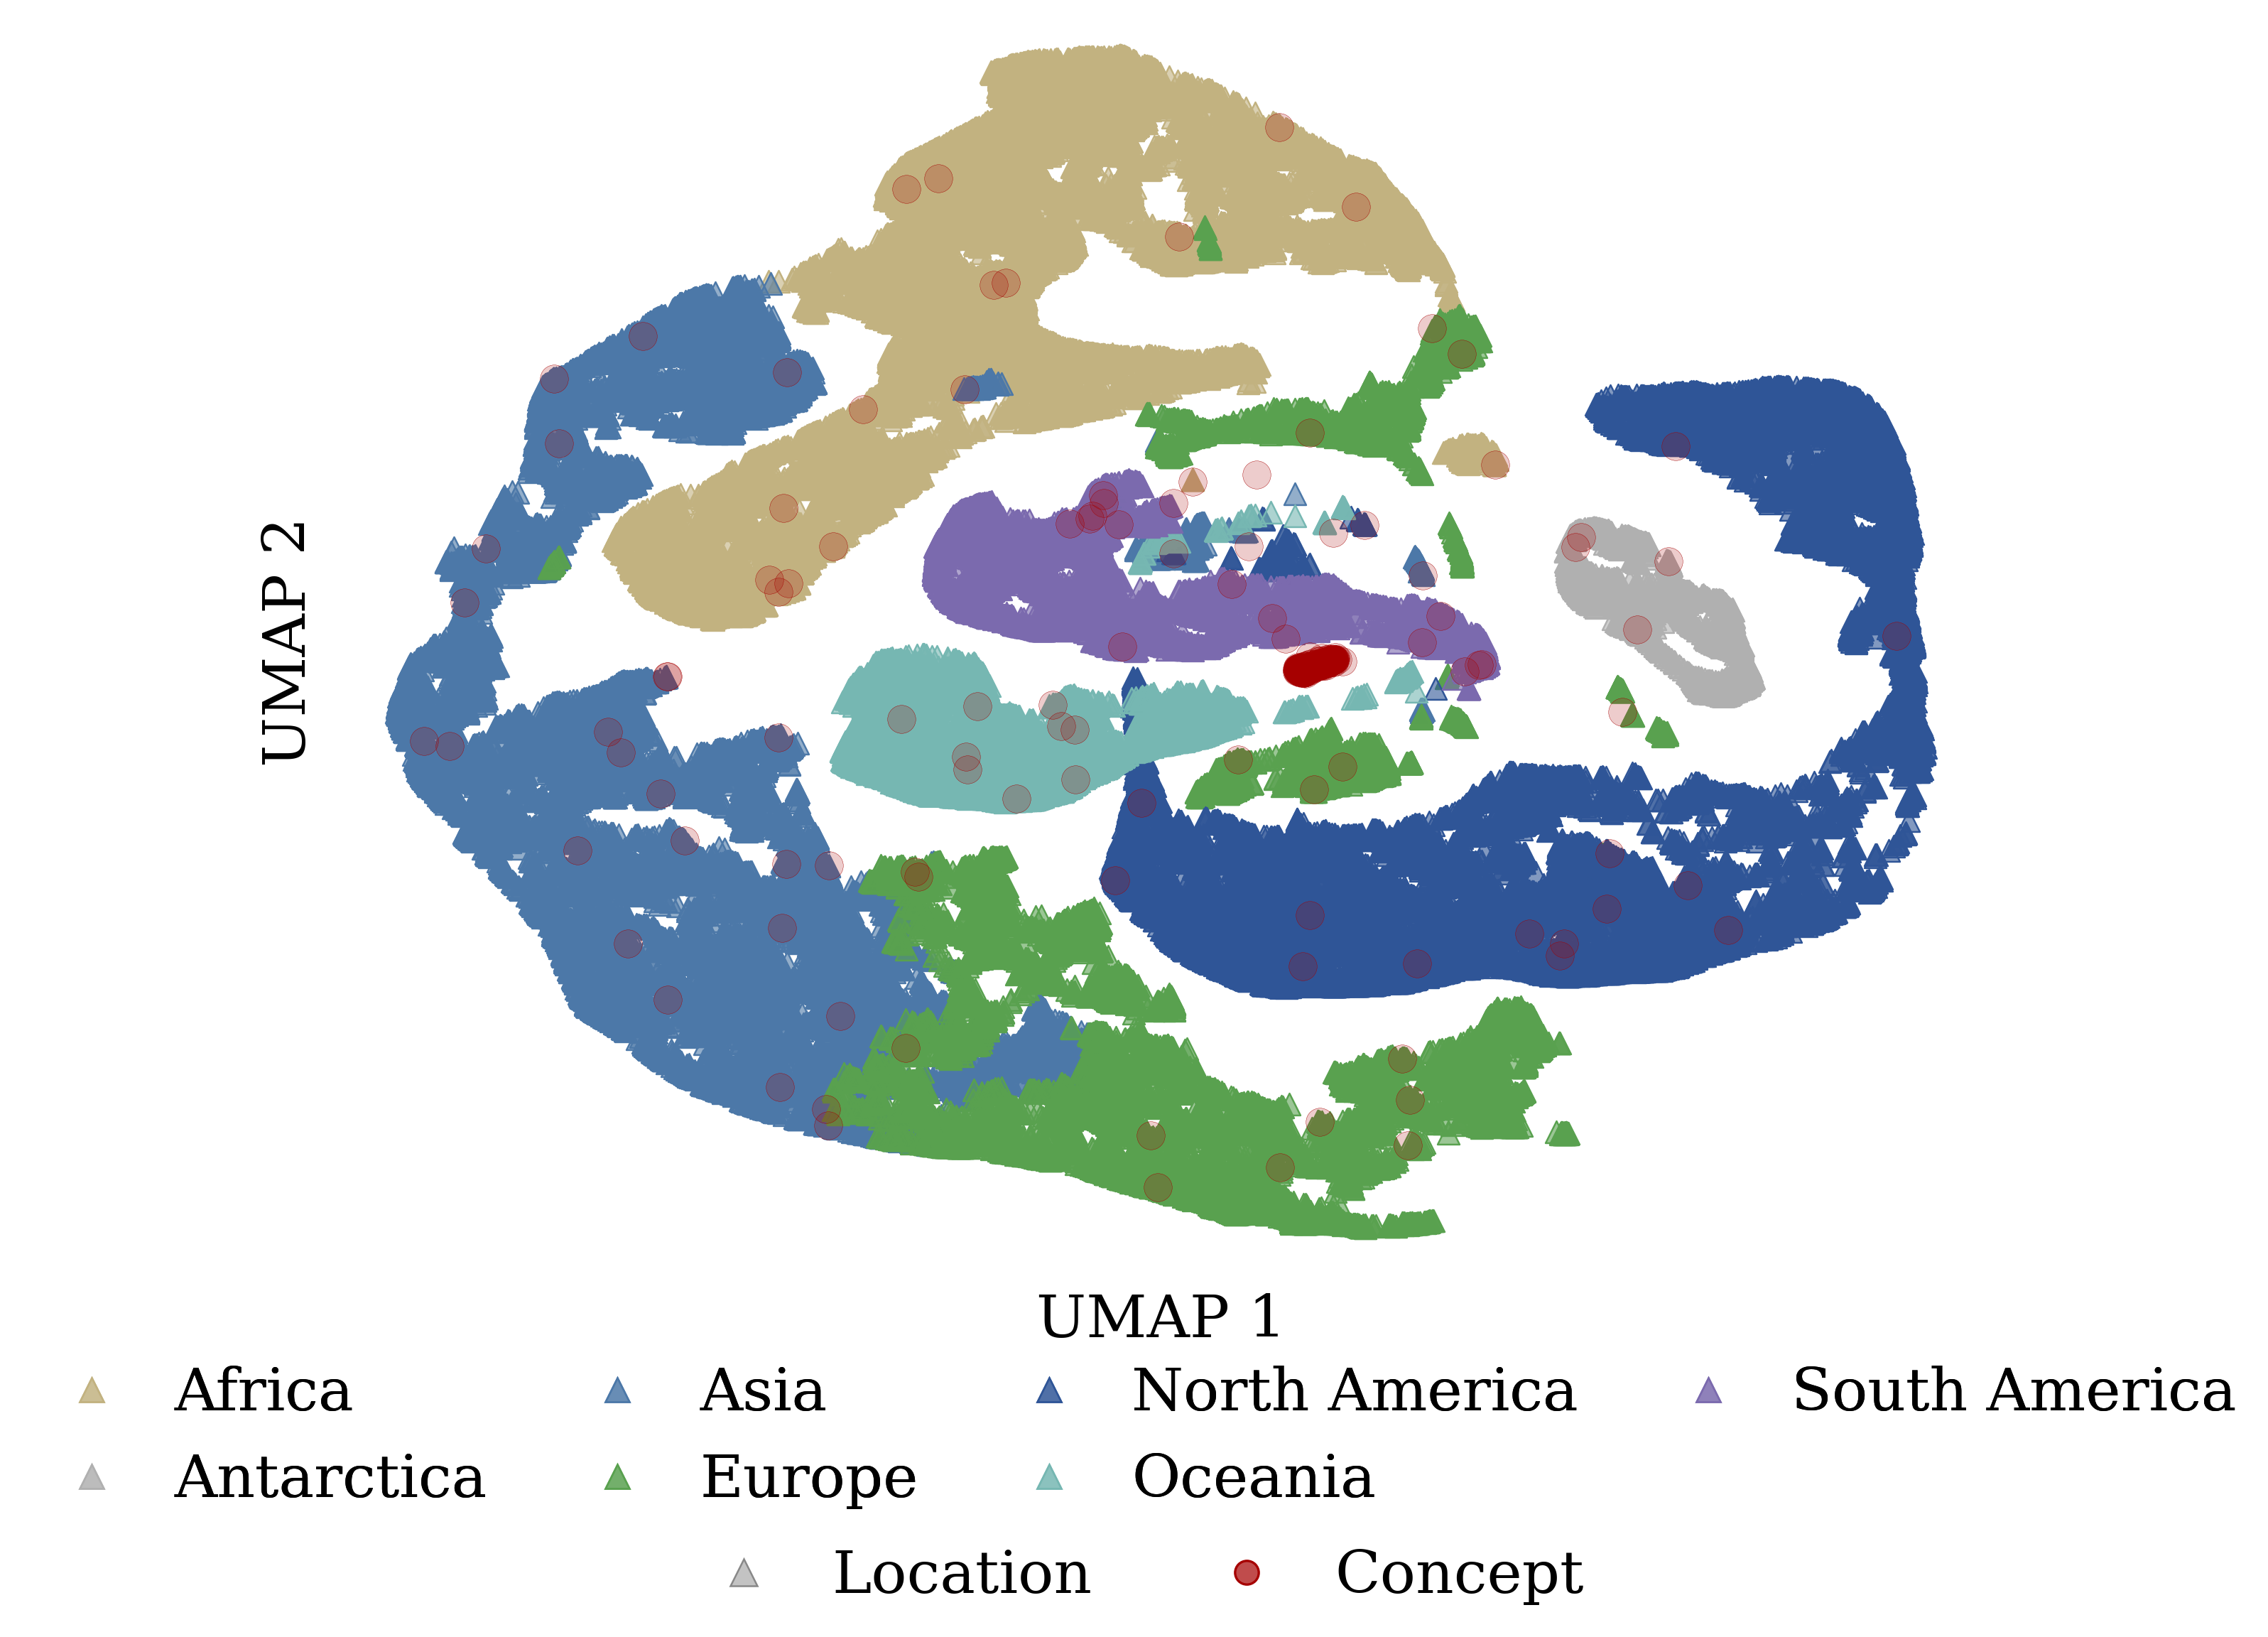

In [21]:
# ── run block ───────────────────────────────────────────────────────────────
for Y_loc, Y_con, method, stem in [
    (Y_umap_loc, Y_umap_con, "UMAP", "umap_mean_centered"),
]:
    fig = make_figure(Y_loc, Y_con, cont_labels, method)

    out = OUTPUT_DIR / f"{stem}.png"
    out.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(out, dpi=300, bbox_inches="tight", facecolor="white")
    print(f"Saved: {out}")

plt.show()